In [87]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

import numpy as np
import matplotlib.pyplot as plt

from qiskit.visualization import plot_distribution
from qiskit.visualization import plot_histogram

from qiskit_aer.primitives import SamplerV2 as Sampler

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


In [88]:
def execute_on_simulater(circuit):
    sim = AerSimulator()

    compiled_circuit = transpile(circuit, sim)

    job = sim.run(compiled_circuit, shots=1024) 
    result = job.result()

    counts = result.get_counts(compiled_circuit)
    print(counts)

    fig = plot_histogram(result.get_counts(compiled_circuit))

    display(fig)
    
    return result

In [89]:
def get_statevector_array(circuit):
    circuit = circuit.copy()
    circuit.save_statevector()
    circuit = transpile(circuit, backend=simulator)
    job = simulator.run(circuit)
    result = job.result()
    qiskit_statevector = result.data()['statevector']

    return np.asarray(qiskit_statevector)

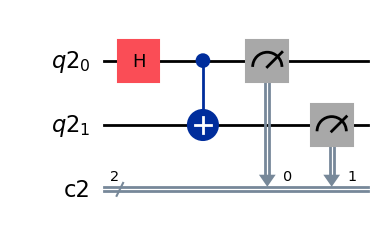

In [90]:
qreg_q2 = QuantumRegister(2, 'q2')
creg_c2 = ClassicalRegister(2, 'c2')

circuit2 = QuantumCircuit(qreg_q2, creg_c2)

circuit2.h(qreg_q2[0])

circuit2.cx(qreg_q2[0], qreg_q2[1])

circuit2.measure(qreg_q2[0], creg_c2[0])
circuit2.measure(qreg_q2[1], creg_c2[1])

circuit2.draw('mpl')


{'11': 511, '00': 513}


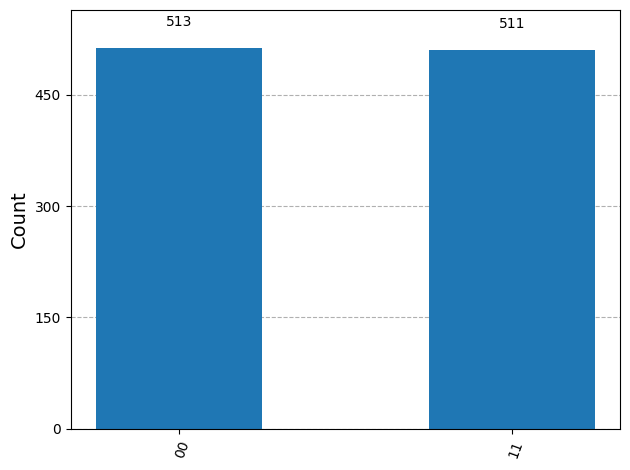

In [91]:
result = execute_on_simulater(circuit2)

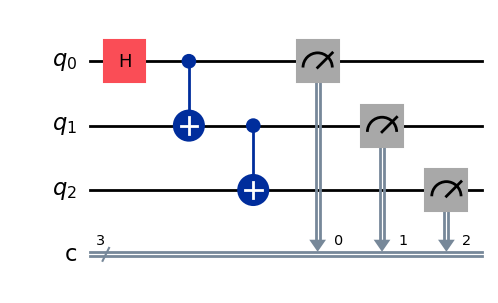

In [92]:
qreg_q3 = QuantumRegister(3, 'q')

creg_c3 = ClassicalRegister(3, 'c')

circuit3 = QuantumCircuit(qreg_q3, creg_c3)

circuit3.h(qreg_q3[0])
circuit3.cx(qreg_q3[0], qreg_q3[1])

circuit3.cx(qreg_q3[1], qreg_q3[2])

circuit3.measure(qreg_q3[0], creg_c3[0])
circuit3.measure(qreg_q3[1], creg_c3[1])
circuit3.measure(qreg_q3[2], creg_c3[2])

circuit3.draw('mpl')


{'111': 528, '000': 496}


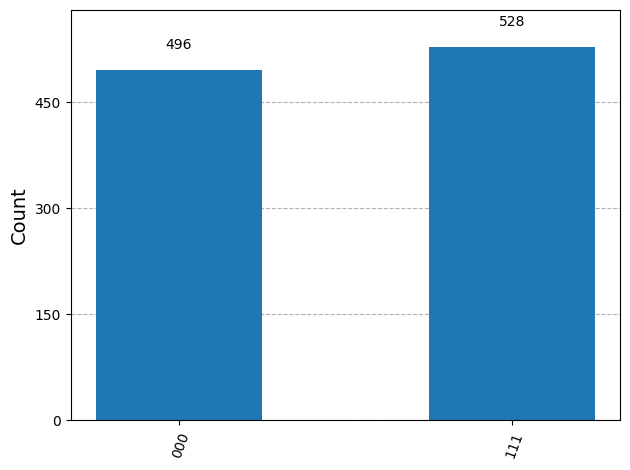

In [93]:
result = execute_on_simulater(circuit3)